# 06 - Quantum Neural Network (EstimatorQNN vs SamplerQNN)

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

Compares Qiskit's two QNN types — **EstimatorQNN** (expectation-value output) and
**SamplerQNN** (measurement-distribution output, parity-interpreted) — each feeding a small
classical logistic "output layer", as required by spec section 9D.

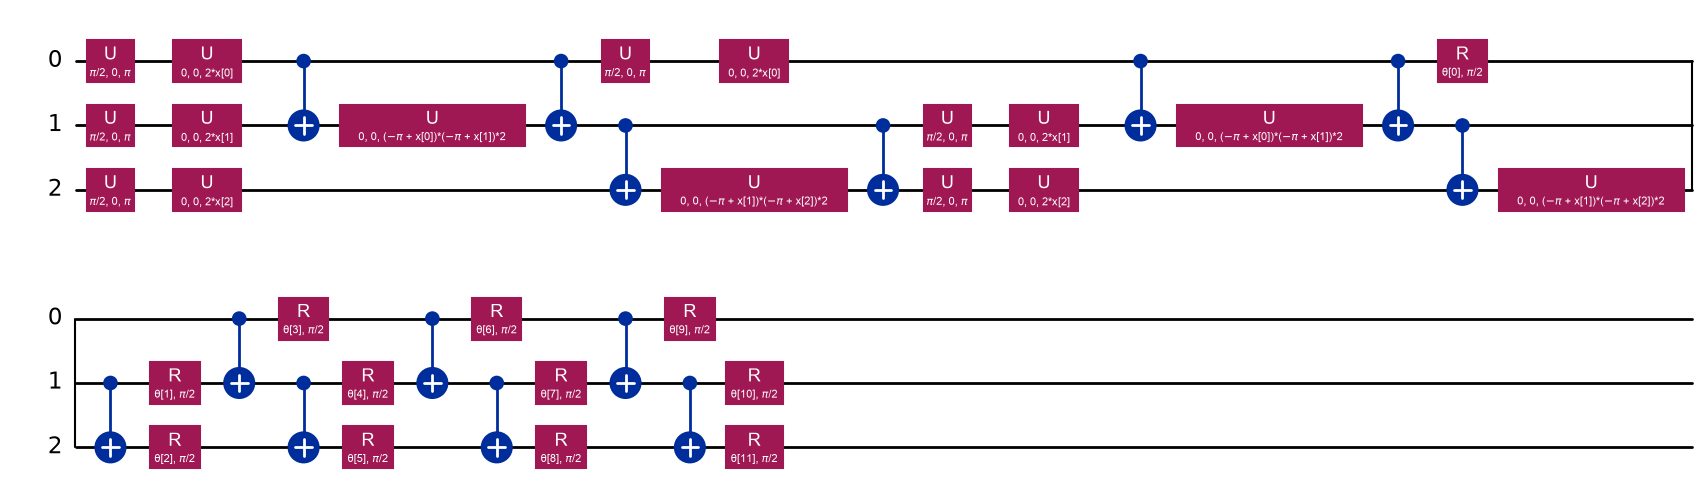

In [2]:
from src.quantum.qnn_model import QNNModel

fig = None
qc_preview = QNNModel(num_qubits=3, qnn_type="estimator", backend="simulator", shots=128,
                       seed=42, optimizer_maxiter=5).circuit.decompose()
fig = qc_preview.draw("mpl", style="iqp")
fig.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\06_qnn_circuit.png", bbox_inches="tight")
fig


In [3]:
import numpy as np
from src.evaluation.metrics import compute_metrics

rng = np.random.default_rng(3)
X = rng.normal(size=(50, 3))
y = (X[:, 0] + X[:, 1] > 0).astype(int)
X_train, y_train = X[:35], y[:35]
X_test, y_test = X[35:], y[35:]

results = {}
for qnn_type in ["estimator", "sampler"]:
    model = QNNModel(num_qubits=3, qnn_type=qnn_type, backend="simulator", shots=256, seed=42,
                      optimizer="cobyla", optimizer_maxiter=40)
    fit_result = model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)
    m = compute_metrics(y_test, proba, threshold=0.5)
    results[qnn_type] = m
    print(qnn_type, fit_result)


estimator QuantumFitResult(training_time_s=1.6042608999996446, n_train=35, num_qubits=3, circuit_depth=26, transpiled_depth=42, shots=256, backend_name='aer_simulator', qnn_type='estimator', optimizer='cobyla')


sampler QuantumFitResult(training_time_s=6.40545950003434, n_train=35, num_qubits=3, circuit_depth=26, transpiled_depth=42, shots=256, backend_name='aer_simulator', qnn_type='sampler', optimizer='cobyla')


In [4]:
metric_names = ["pr_auc", "roc_auc", "recall", "precision", "f1", "fpr"]
comparison = pd.DataFrame({k: [getattr(v, m) for m in metric_names] for k, v in results.items()}, index=metric_names)
comparison


,estimator,sampler
pr_auc,0.598392,0.830760
roc_auc,0.462963,0.722222
recall,0.111111,0.000000
precision,0.333333,0.000000
f1,0.166667,0.000000
fpr,0.333333,0.000000


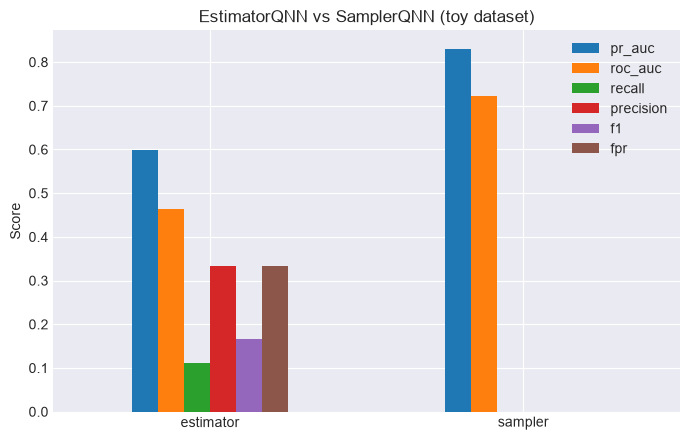

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
comparison.T.plot(kind="bar", ax=ax)
ax.set_title("EstimatorQNN vs SamplerQNN (toy dataset)")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\06_qnn_comparison.png")
plt.show()
